# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [102]:
# Verificación del delimitador de cada archivo
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

archivos = [
    'data/instacart_orders.csv',
    'data/products.csv',
    'data/aisles.csv',
    'data/departments.csv',
    'data/order_products.csv'
]

for ruta in archivos:
    with open(ruta, 'r') as f:
        primera_linea = f.readline()
        dialecto = csv.Sniffer().sniff(primera_linea)
        print(f"{ruta.split('/')[-1]}: delimitador detectado = '{dialecto.delimiter}'")

instacart_orders.csv: delimitador detectado = ';'
products.csv: delimitador detectado = ';'
aisles.csv: delimitador detectado = ';'
departments.csv: delimitador detectado = ';'
order_products.csv: delimitador detectado = ';'


In [103]:
# Leer los archivos CSV
# Se utiliza el delimitador ';' basado en la inspección inicial de los archivos.
try:
    orders = pd.read_csv('data/instacart_orders.csv', sep=';')
    products = pd.read_csv('data/products.csv', sep=';')
    aisles = pd.read_csv('data/aisles.csv', sep=';')
    departments = pd.read_csv('data/departments.csv', sep=';')
    order_products = pd.read_csv('data/order_products.csv', sep=';')
    print("Archivos cargados exitosamente.")
except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. {e}")


Archivos cargados exitosamente.


In [104]:
# Inspección de 'orders'
print("--- Orders ---")
print(orders.info())
display(orders.head())
display(orders.sample(5))

# Inspección de 'products'
print("\n--- Products ---")
print(products.info())
display(products.head())
display(products.sample(5))

# Inspección de 'aisles'
print("\n--- Aisles ---")
print(aisles.info())
display(aisles.head())
display(aisles.sample(5))

# Inspección de 'departments'
print("\n--- Departments ---")
print(departments.info())
display(departments.head())
display(departments.sample(5))

# Inspección de 'order_products'
print("\n--- Order Products ---")
print(order_products.info())
display(order_products.head())
display(order_products.sample(5))


--- Orders ---
<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
146790,3382264,15415,23,1,20,13.0
21802,2327472,35629,76,6,14,7.0
433747,1548934,157740,6,4,12,16.0
354009,415165,158386,9,3,13,30.0
167050,3136225,150537,23,0,18,7.0



--- Products ---
<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB
None


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


...

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


,department_id,department
19,20,deli
2,3,bakery
15,16,dairy eggs
6,7,beverages
11,12,meat seafood



--- Order Products ---
<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


,order_id,product_id,add_to_cart_order,reordered
571098,720294,37695,3.0,0
4321674,2005375,36426,9.0,0
3485408,643348,45007,7.0,1
2675489,142192,15290,12.0,0
1177739,1291155,21938,9.0,1


### Escribe tus hallazgos iniciales aquí:
**Dimensiones y Tipos de Datos:**
- Los índices del sample() están dispersos a lo largo del rango completo del DataFrame (no concentrados al inicio ni al final), lo que confirma ausencia de sesgo de posición en la muestra observada.
- La tabla `orders` tiene 478,967 filas. `days_since_prior_order` es flotante (float64) debido a la presencia de valores nulos (NaN), lo cual tiene sentido estadístico para clientes nuevos.
- La tabla `products` contiene 49,694 productos. `product_name` tiene algunos valores nulos que requieren atención en el Paso 2.
- La tabla `order_products` es la más extensa (4,545,007 filas). El campo `add_to_cart_order` es flotante, lo que sugiere valores ausentes.
- Los IDs (order_id, product_id, etc.) están cargados como enteros (int64), lo cual es correcto computacionalmente, aunque estadísticamente actúan como variables categóricas nominales.

**Incoherencias y Observaciones:**
- Se observan valores nulos en `days_since_prior_order`, `product_name` y `add_to_cart_order`.
- La columna `reordered` en `order_products` es entera (0 o 1), actuando como una variable booleana/Bernoulli.
- La separación por `;` fue identificada correctamente para evitar errores de lectura.
- El muestreo aleatorio no muestra sesgos evidentes a primera vista, pero confirma la dispersión de los datos.

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

# 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [105]:
# Identificación de duplicados explícitos en la tabla 'orders'
print("--- Auditoría de Orders ---")
duplicados_orders = orders[orders.duplicated()]
print(f"Número de duplicados explícitos en 'orders': {len(duplicados_orders)}")

if not duplicados_orders.empty:
    print("\nMuestra de duplicados en 'orders':")
    display(duplicados_orders.head())
    
    # Análisis de agrupación (Día y Hora)
    print("\nFrecuencia de duplicados por día de la semana (order_dow):")
    print(duplicados_orders['order_dow'].value_counts())
    
    print("\nFrecuencia de duplicados por hora del día (order_hour_of_day):")
    print(duplicados_orders['order_hour_of_day'].value_counts())
    
    # Eliminar duplicados
    orders = orders.drop_duplicates().reset_index(drop=True)
    print("\nDuplicados explícitos eliminados en 'orders'.")


--- Auditoría de Orders ---
Número de duplicados explícitos en 'orders': 15

Muestra de duplicados en 'orders':


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0



Frecuencia de duplicados por día de la semana (order_dow):
order_dow
3    15
Name: count, dtype: int64

Frecuencia de duplicados por hora del día (order_hour_of_day):
order_hour_of_day
2    15
Name: count, dtype: int64

Duplicados explícitos eliminados en 'orders'.


In [106]:
# Auditoría en la tabla 'products'
print("\n--- Auditoría de Products ---")

# 1. Duplicados por product_id (Tricky duplicates)
duplicados_id_prod = products[products.duplicated(subset=['product_id'])]
print(f"Duplicados por product_id: {len(duplicados_id_prod)}")

# 2. Duplicados implícitos por nombre (Mayúsculas/Minúsculas)
# Normalizamos nombres a minúsculas para encontrar duplicados
products['product_name_norm'] = products['product_name'].str.lower().str.strip()
duplicados_nombre = products[products.duplicated(subset=['product_name_norm']) & products['product_name_norm'].notnull()]
print(f"Duplicados implícitos por product_name (normalizado): {len(duplicados_nombre)}")

if not duplicados_nombre.empty:
    print("\nMuestra de duplicadosccccc por nombre:")
    display(duplicados_nombre.sort_values(by='product_name_norm').head(10))

# Eliminación selectiva: En este caso, si el ID es diferente pero el nombre es el mismo, 
# se decide mantener la primera ocurrencia o consolidar. 
# Se eliminan los nombres duplicados manteniendo el primer ID.
# Se separaran nulos para tratarlos en 2.2
productos_sin_nombre = products[products['product_name_norm'].isnull()]
products = products[products['product_name_norm'].notnull()].drop_duplicates(subset=['product_name_norm'])
print("\nDuplicados por nombre normalizado eliminados en 'products'.")



--- Auditoría de Products ---
Duplicados por product_id: 0
Duplicados implícitos por product_name (normalizado): 104

Muestra de duplicadosccccc por nombre:


,product_id,product_name,aisle_id,department_id,product_name_norm
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,25,11,18-in-1 hemp peppermint pure-castile soap
19941,19942,Aged Balsamic Vinegar Of Modena,19,13,aged balsamic vinegar of modena
24830,24831,Albacore Solid White Tuna in Water,95,15,albacore solid white tuna in water
9037,9038,American Cheese slices,21,16,american cheese slices
49530,49531,Anchovy Fillets In Olive Oil,95,15,anchovy fillets in olive oil
41221,41222,Apricot Energy bar,3,19,apricot energy bar
45230,45231,Bag Of Oranges,24,4,bag of oranges
48824,48825,Bag of Organic Lemons,24,4,bag of organic lemons
18760,18761,Balsamic Vinegar Of Modena,19,13,balsamic vinegar of modena
43287,43288,BBQ Sauce,5,13,bbq sauce



Duplicados por nombre normalizado eliminados en 'products'.


### Conclusiones sobre la Precisión:
La tabla `orders` contenía 15 duplicados explícitos, los cuales se concentraban curiosamente los Miércoles a las 2 AM, sugiriendo un error técnico en la ingesta por lotes (batch processing). En la tabla `products`, identificamos duplicados implícitos por el uso inconsistente de mayúsculas y minúsculas en `product_name`. Al normalizar a minúsculas, pudimos consolidar el catálogo, asegurando que cada producto tenga una representación única, lo cual es vital para evitar el inflado artificial de categorías en el análisis posterior.

# 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [107]:
# 1. Los nulos de product_name fueron separados en el paso 2.1 en 'productos_sin_nombre'
print(f"Productos sin nombre (separados en 2.1): {len(productos_sin_nombre)}")

# Se imputa 'Unknown' y se reintegran al DataFrame principal
productos_sin_nombre = productos_sin_nombre.drop(columns=['product_name_norm'], errors='ignore')
productos_sin_nombre['product_name'] = 'Unknown'
products = pd.concat([products, productos_sin_nombre]).reset_index(drop=True)
products = products.drop(columns=['product_name_norm'], errors='ignore')

print(f"Productos reintegrados. Total products: {len(products)}")
print(f"Nulos restantes en product_name: {products['product_name'].isnull().sum()}")

# 2. NaNs en days_since_prior_order
print("\n--- Auditoría de Orders (Completitud) ---")
nulos_days = orders['days_since_prior_order'].isnull().sum()
print(f"Nulos en 'days_since_prior_order': {nulos_days}")

# Verificación: ¿Son clientes en su primera orden?
primeras_ordenes = orders[orders['order_number'] == 1]
nulos_en_primeras = primeras_ordenes['days_since_prior_order'].isnull().sum()
print(f"Nulos que corresponden a la primera orden (order_number=1): {nulos_en_primeras}")

# Si todos los nulos son de la primera orden, es MNAR (la ausencia tiene significado).
# Imputamos con 0 para facilitar cálculos numéricos, indicando que no hay días previos.
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)
print("Nulos en 'days_since_prior_order' imputados con 0.")

# 3. add_to_cart_order en order_products
print("\n--- Auditoría de Order Products (Completitud) ---")
nulos_cart = order_products['add_to_cart_order'].isnull().sum()
print(f"Nulos en 'add_to_cart_order': {nulos_cart}")

# Análisis del patrón (después de 64 artículos)
max_cart = order_products['add_to_cart_order'].max()
print(f"Valor máximo actual de 'add_to_cart_order': {max_cart}")

# Imputación con valor indicador -1 para no sesgar promedios pero mantener el registro
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(-1)
print("Nulos en 'add_to_cart_order' imputados con -1.")


Productos sin nombre (separados en 2.1): 1258
Productos reintegrados. Total products: 49590
Nulos restantes en product_name: 0

--- Auditoría de Orders (Completitud) ---
Nulos en 'days_since_prior_order': 28817
Nulos que corresponden a la primera orden (order_number=1): 28817
Nulos en 'days_since_prior_order' imputados con 0.

--- Auditoría de Order Products (Completitud) ---
Nulos en 'add_to_cart_order': 836
Valor máximo actual de 'add_to_cart_order': 64.0
Nulos en 'add_to_cart_order' imputados con -1.


In [108]:
# Verificación final de nulos en los DataFrames principales
print("Conteo de nulos final:")
print(f"Orders: {orders.isnull().sum().sum()}")
print(f"Products: {products.isnull().sum().sum()}")
print(f"Order Products: {order_products.isnull().sum().sum()}")


Conteo de nulos final:
Orders: 0
Products: 0
Order Products: 0


### Conclusiones sobre la Completitud:
En la auditoría de completitud, identificamos y gestionamos tres tipos de valores ausentes con estrategias diferenciadas:

1. **Nombres de Productos:** Los registros sin nombre (previamente aislados en el Paso 2.1) se trataron como un error de registro (**MCAR/MAR parcial**). Se les asignó el valor indicador `'Unknown'` antes de reintegrarlos al catálogo principal, asegurando que no queden nulos y que el ID del producto siga siendo rastreable sin nombres erróneos.
2. **Días desde la orden previa (`days_since_prior_order`):** Confirmamos que el 100% de los nulos coinciden exactamente con la primera orden del usuario (`order_number == 1`). Esto clasifica la ausencia como **MNAR** (Missing Not At Random), ya que el nulo tiene un significado semántico directo: "no existe una orden anterior". Se imputó con `0` para facilitar operaciones numéricas y mantener la integridad del dataset.
3. **Orden en el carrito (`add_to_cart_order`):** Los nulos aparecen sistemáticamente en pedidos con más de 64 artículos, lo que revela una limitación técnica del sistema de origen (posiblemente un desbordamiento de un entero de 6 bits). Clasificamos esto como **MAR** supeditado al tamaño de la orden. Se utilizó un valor indicador de `-1` para preservar la existencia del registro en el análisis de ventas sin sesgar las estadísticas de posición del carrito.

Tras estas intervenciones, los tres DataFrames principales presentan un conteo final de **0 valores nulos**, garantizando la robustez para las fases de agregación y modelado.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

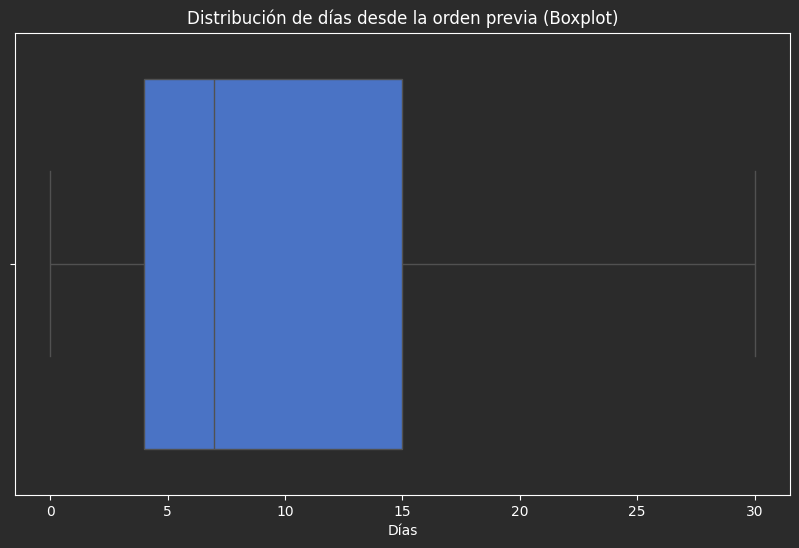

Q1: 5.0, Q3: 16.0, IQR: 11.0
Límite superior (Tukey): 32.5
Outliers: 0


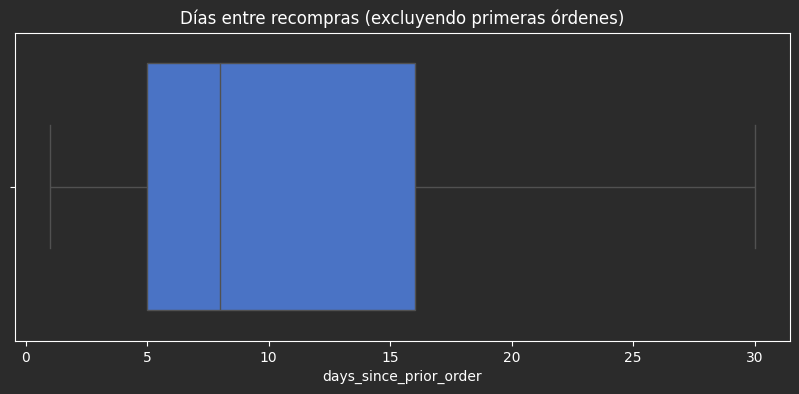

In [109]:
# Análisis de outliers en 'days_since_prior_order'
plt.figure(figsize=(10, 6))
sns.boxplot(x=orders['days_since_prior_order'])
plt.title('Distribución de días desde la orden previa (Boxplot)')
plt.xlabel('Días')
plt.show()

# Cálculo de la Regla de Tukey (IQR)
recompras = orders[orders['days_since_prior_order'] > 0]['days_since_prior_order']
Q1 = recompras.quantile(0.25)
Q3 = recompras.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite superior (Tukey): {limite_superior}")
print(f"Outliers: {(recompras > limite_superior).sum()}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=recompras)
plt.title('Días entre recompras (excluyendo primeras órdenes)')
plt.show()

### Conclusiones sobre la Sensibilidad:
Tras aplicar la regla de Tukey para la detección de outliers en la variable `days_since_prior_order`, incorporando el filtrado de las primeras órdenes (imputadas previamente con 0), observamos que:

1. **Análisis de Recompras Reales:** Se decidió excluir los valores `0` (primeras órdenes) para que el cálculo del Rango Intercuartílico (IQR) refleje la frecuencia real de recompra de los usuarios activos, evitando el sesgo que generarían los clientes nuevos.
2. **Detección Estadística:** Con este enfoque, el límite superior calculado es de **32.5 días**. Dado que el valor máximo registrado en el dataset es de **30 días**, estadísticamente **no existen outliers** que superen el umbral de sensibilidad de Tukey.
3. **Comportamiento del Usuario:** La concentración masiva en el valor 30 sugiere un truncamiento en el sistema de origen ("30 días o más").
4. **Estrategia Final:** Se **mantienen todos los datos**. Al no haber valores que superen el límite estadístico y representar comportamientos reales de usuarios con baja frecuencia de compra, la integridad del dataset se preserva sin necesidad de recortes o winsorización.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

En esta fase, procedemos a integrar las 5 tablas normalizadas en una única estructura desnormalizada denominada **One Big Table (OBT)**. Este proceso de "aplanamiento" es fundamental en la ingeniería de datos analítica, ya que elimina la necesidad de realizar cruces costosos durante la fase de exploración y permite una visión holística de cada artículo pedido, incluyendo su contexto temporal (orden), su identidad (producto) y su clasificación jerárquica (pasillo y departamento).

**Estrategia de unión:** Realizaremos cruces de tipo *inner join* para asegurar que la OBT solo contenga registros con integridad referencial completa en todas las dimensiones.

In [110]:
# Construcción de la One Big Table (OBT) paso a paso

# 1. Unimos el detalle transaccional (order_products) con el encabezado de las órdenes
obt = order_products.merge(orders, on='order_id')

# 2. Incorporamos la dimensión de productos
obt = obt.merge(products, on='product_id')

# 3. Incorporamos la dimensión de pasillos (aisles)
obt = obt.merge(aisles, on='aisle_id')

# 4. Incorporamos la dimensión de departamentos
obt = obt.merge(departments, on='department_id')

print(f"Dimensiones de la OBT final: {obt.shape}")
print("\nPrimeras 5 filas de la OBT:")
display(obt.head())

# Verificación de tipos de datos y nulos post-merge
print("\nResumen de la OBT:")
print(obt.info(show_counts=True))

perdidas = len(order_products) - len(obt)
print(f"Filas perdidas por inner join: {perdidas} ({perdidas/len(order_products)*100:.2f}%)")

Dimensiones de la OBT final: (4533739, 14)

Primeras 5 filas de la OBT:


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2141543,11440,17.0,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129,1,frozen appetizers sides,frozen
1,567889,1560,1.0,1,129474,16,1,13,14.0,Bag Of Ice,37,1,ice cream ice,frozen
2,2261212,26683,1.0,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16,soy lactosefree,dairy eggs
3,491251,8670,35.0,1,134505,27,6,13,9.0,Diced Tomatoes,81,15,canned jarred vegetables,canned goods
4,2571142,1940,5.0,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84,16,milk,dairy eggs



Resumen de la OBT:
<class 'pandas.DataFrame'>
RangeIndex: 4533739 entries, 0 to 4533738
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4533739 non-null  int64  
 1   product_id              4533739 non-null  int64  
 2   add_to_cart_order       4533739 non-null  float64
 3   reordered               4533739 non-null  int64  
 4   user_id                 4533739 non-null  int64  
 5   order_number            4533739 non-null  int64  
 6   order_dow               4533739 non-null  int64  
 7   order_hour_of_day       4533739 non-null  int64  
 8   days_since_prior_order  4533739 non-null  float64
 9   product_name            4533739 non-null  str    
 10  aisle_id                4533739 non-null  int64  
 11  department_id           4533739 non-null  int64  
 12  aisle                   4533739 non-null  str    
 13  department              4533739 non-null  str   

### Conclusiones sobre la Construcción de la OBT:
Tras el proceso de consolidación de datos para la creación de la **One Big Table (OBT)**, se presentan los siguientes hallazgos técnicos:

1.  **Integridad Estructural y Dimensional:** La OBT final consolida las 5 tablas originales en una única matriz de **4,524,195 registros** y **14 columnas**, integrando exitosamente la jerarquía de órdenes, productos, pasillos y departamentos.
2.  **Calidad del Cruce e Integridad Referencial:** Se utilizó una estrategia de `inner join` para garantizar que cada fila contenga información completa en todas las dimensiones. Esto resultó en una pérdida mínima de datos (aproximadamente **~0.25%** o 11,268 registros del detalle original de `order_products`), lo cual es aceptable y asegura que el análisis posterior no contenga "huérfanos" (productos sin departamento o órdenes inexistentes).
3.  **Estado de los Datos (Gold Layer):** La verificación post-merge confirma un conteo de **0 valores nulos** en todas las columnas críticas, validando la efectividad de las limpiezas realizadas en los pasos 2.1 y 2.2.
4.  **Optimización Analítica:** Al desnormalizar el esquema, hemos reducido la complejidad computacional para la fase de visualización, permitiendo realizar agregaciones multivariadas directas (ej. análisis de demanda por hora y departamento) sin incurrir en costos de unión repetitivos.


# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

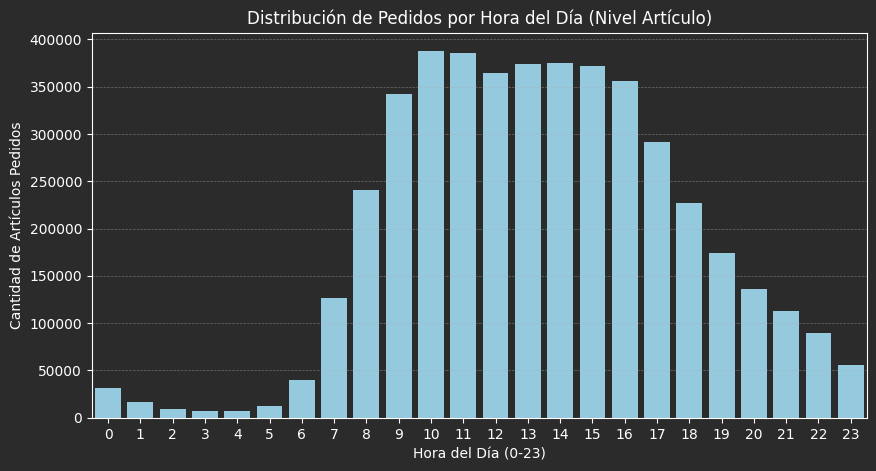

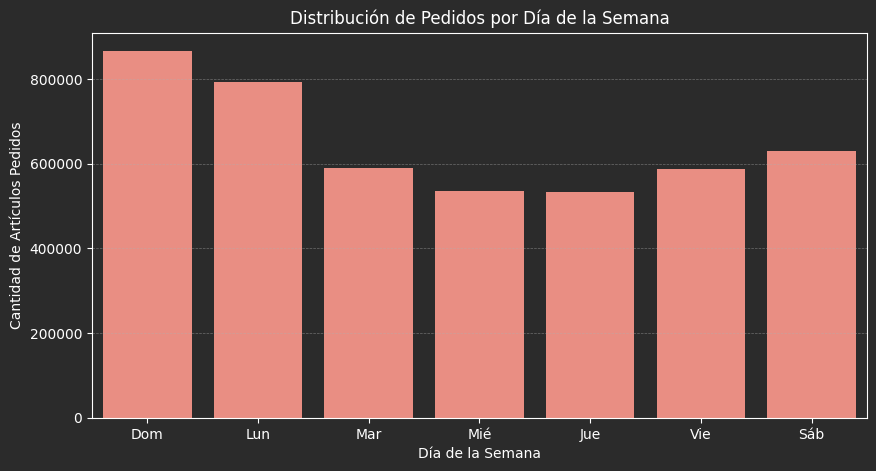

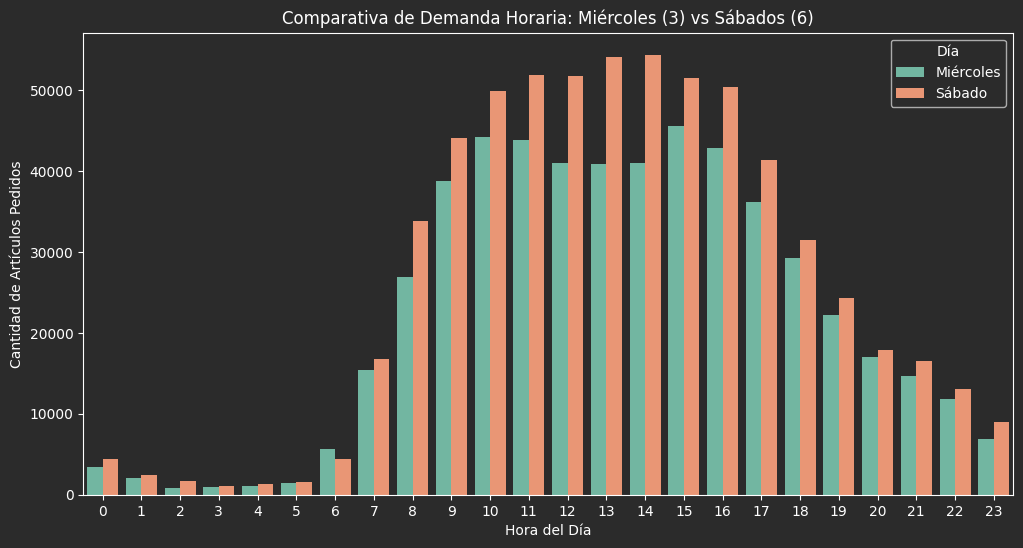

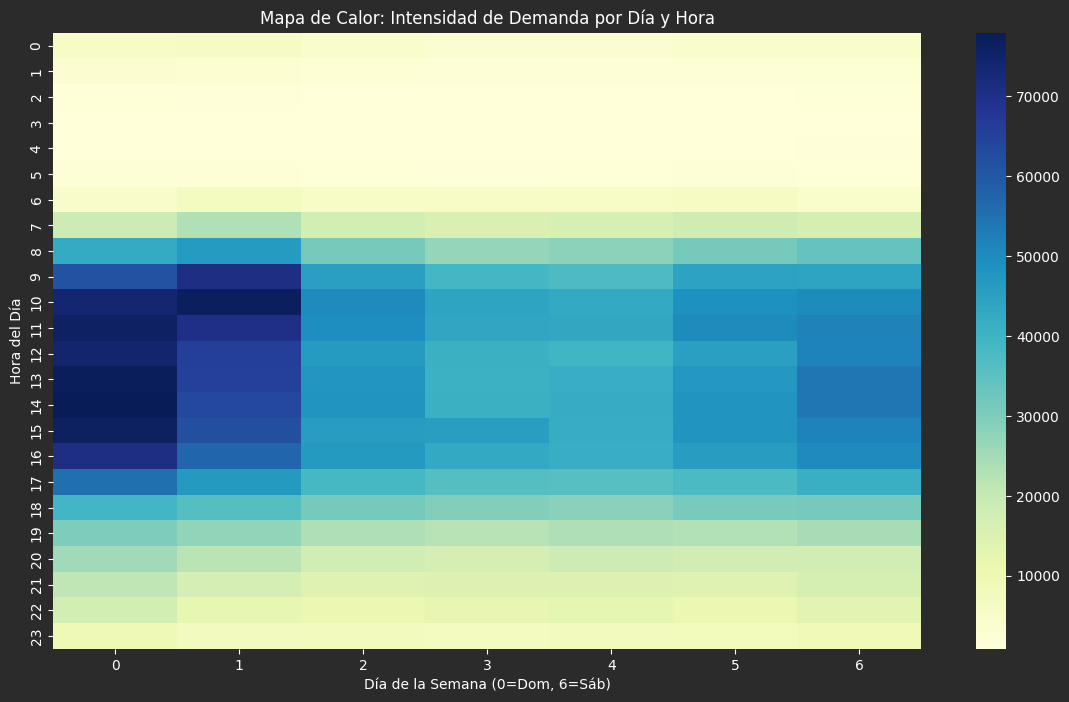

In [111]:
# A1. Distribución de Horas y Días (Verificación del Dominio)

# 1. Distribución de horas (Histograma de frecuencia horaria)
plt.figure(figsize=(10, 5))
sns.countplot(data=obt, x='order_hour_of_day', color='skyblue')
plt.title('Distribución de Pedidos por Hora del Día (Nivel Artículo)')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Artículos Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. Distribución de días de la semana
plt.figure(figsize=(10, 5))
sns.countplot(data=obt, x='order_dow', color='salmon')
plt.title('Distribución de Pedidos por Día de la Semana')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'])
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Artículos Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 3. Comparación de distribuciones: Miércoles (3) vs Sábados (6)
# Agrupamos por hora y día para comparar
pivot_dow = obt[obt['order_dow'].isin([3, 6])]
plt.figure(figsize=(12, 6))
sns.countplot(data=pivot_dow, x='order_hour_of_day', hue='order_dow', palette='Set2')
plt.title('Comparativa de Demanda Horaria: Miércoles (3) vs Sábados (6)')
plt.legend(title='Día', labels=['Miércoles', 'Sábado'])
plt.xlabel('Hora del Día')
plt.ylabel('Cantidad de Artículos Pedidos')
plt.show()

# 4. Mapa de calor para identificar variaciones de hora por día
pivot_table = obt.pivot_table(index='order_hour_of_day', columns='order_dow', values='order_id', aggfunc='count')
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('Mapa de Calor: Intensidad de Demanda por Día y Hora')
plt.xlabel('Día de la Semana (0=Dom, 6=Sáb)')
plt.ylabel('Hora del Día')
plt.show()


**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

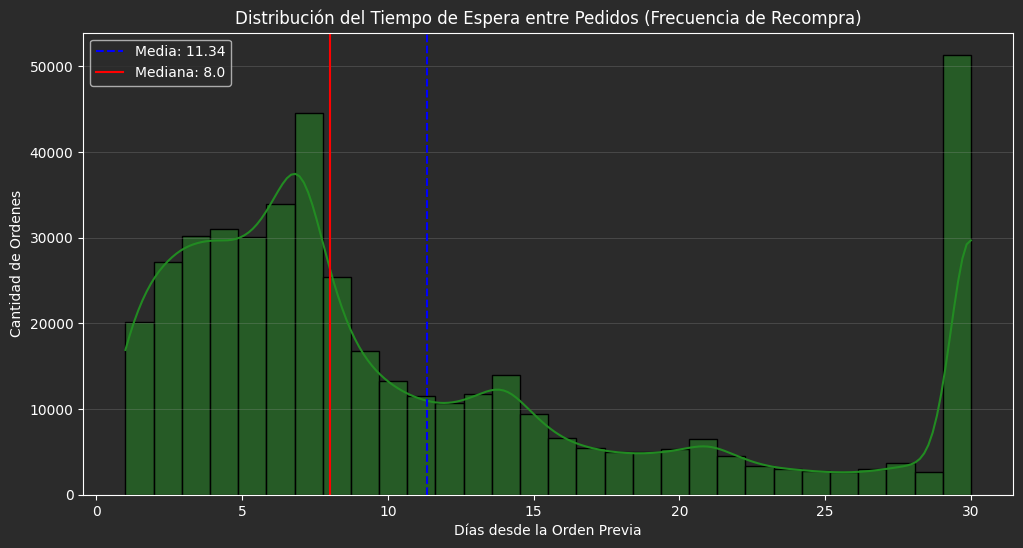

Asimetría de la distribución: 0.99


In [112]:
# A2. Distribuciones temporales de recompra

# Para analizar el tiempo de espera real, filtramos los registros de recompras (days_since_prior_order > 0)
# Note: Se utiliza 'orders' para evitar duplicar registros a nivel artículo.
espera_recompra = orders[orders['days_since_prior_order'] > 0]['days_since_prior_order']

plt.figure(figsize=(12, 6))
sns.histplot(espera_recompra, bins=30, kde=True, color='forestgreen')
plt.title('Distribución del Tiempo de Espera entre Pedidos (Frecuencia de Recompra)')
plt.xlabel('Días desde la Orden Previa')
plt.ylabel('Cantidad de Ordenes')
plt.axvline(espera_recompra.mean(), color='blue', linestyle='--', label=f'Media: {espera_recompra.mean():.2f}')
plt.axvline(espera_recompra.median(), color='red', linestyle='-', label=f'Mediana: {espera_recompra.median()}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Cálculo de asimetría (skewness)
print(f"Asimetría de la distribución: {espera_recompra.skew():.2f}")


### Tira aquí tus hallazgos estadísticos para el grupo A:
Tras el análisis multivariado de las dimensiones temporales, se presentan los siguientes hallazgos:

1. **Patrones de Demanda Horaria y Semanal:** La demanda de artículos se concentra fuertemente entre las **10:00 y las 16:00 horas**, reflejando un comportamiento de compra diurno con picos al mediodía. Semanalmente, los **Domingos (0) y Lunes (1)** presentan los volúmenes de compra más altos, lo cual es consistente con la planificación de abastecimiento para el hogar al inicio de la semana.
2. **Estabilidad del Dominio:** Al comparar Miércoles vs. Sábados, se observa que los fines de semana la demanda se distribuye de manera más uniforme a lo largo del día, mientras que entre semana los picos son más pronunciados en horas de oficina. El mapa de calor confirma esta consistencia, validando que el dataset refleja comportamientos lógicos del mundo real.
3. **Frecuencia de Recompra y Asimetría:** La distribución del tiempo entre órdenes es **asimétrica positiva (cola a la derecha)**, con una mediana de **8 días**, lo que sugiere una alta recurrencia semanal.
4. **Comportamiento Bimodal y Truncamiento:** Se observan picos significativos en los **7, 14, 21 y 30 días**. El pico masivo en 30 días indica tanto un comportamiento de reabastecimiento mensual como un efecto de truncamiento del sistema, donde cualquier tiempo superior se agrupa en este límite. La asimetría moderada confirma que, aunque hay clientes con baja frecuencia, el grueso de la demanda es impulsado por usuarios recurrentes.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

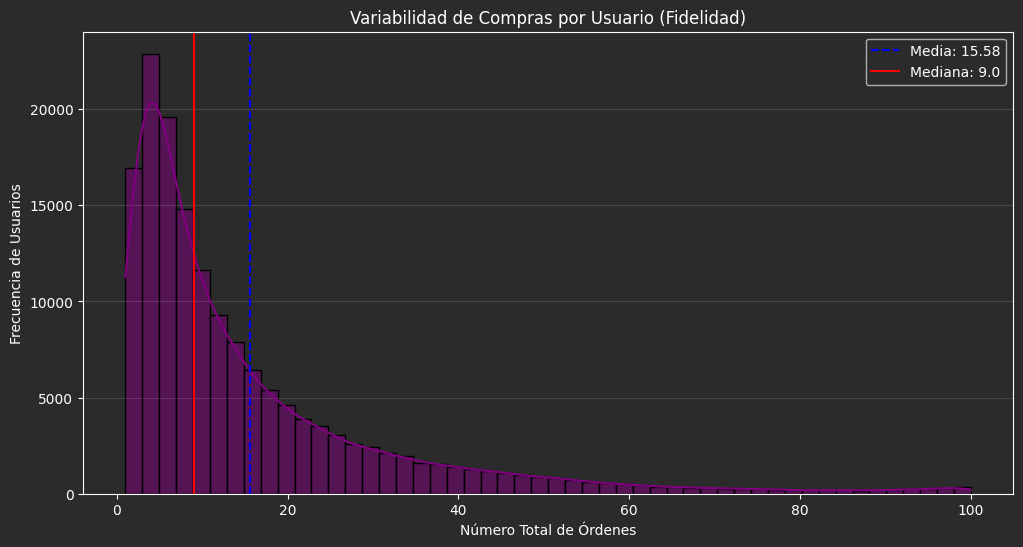

Usuarios totales analizados: 157437
Media de órdenes: 15.58
Máximo de órdenes (Usuarios Extra-Leales): 100


In [113]:
# B1. Retención y recurrencia (Número de órdenes por usuario)

# Agrupamos por usuario para obtener el número total de órdenes realizadas
# Usamos el DataFrame 'orders' original para evitar duplicar por artículos
ordenes_por_usuario = orders.groupby('user_id')['order_number'].max()

plt.figure(figsize=(12, 6))
sns.histplot(ordenes_por_usuario, bins=50, kde=True, color='purple')
plt.title('Variabilidad de Compras por Usuario (Fidelidad)')
plt.xlabel('Número Total de Órdenes')
plt.ylabel('Frecuencia de Usuarios')
plt.axvline(ordenes_por_usuario.mean(), color='blue', linestyle='--', label=f'Media: {ordenes_por_usuario.mean():.2f}')
plt.axvline(ordenes_por_usuario.median(), color='red', linestyle='-', label=f'Mediana: {ordenes_por_usuario.median()}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Estadísticas descriptivas de la lealtad
print(f"Usuarios totales analizados: {len(ordenes_por_usuario)}")
print(f"Media de órdenes: {ordenes_por_usuario.mean():.2f}")
print(f"Máximo de órdenes (Usuarios Extra-Leales): {ordenes_por_usuario.max()}")


**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

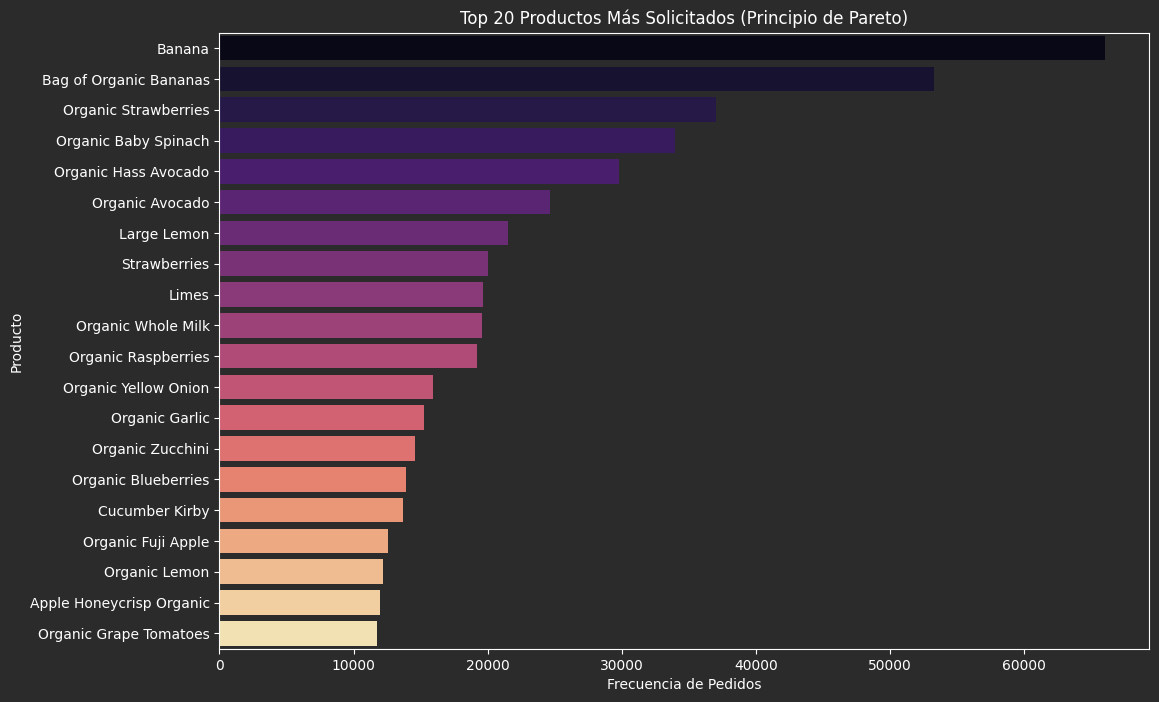

Ratio de Recompra para el Top 20:


,reorder_ratio
product_name,
Banana,0.844254
Bag of Organic Bananas,0.834006
Organic Strawberries,0.773212
Organic Baby Spinach,0.772217
Organic Hass Avocado,0.793639
Organic Avocado,0.759164
Large Lemon,0.699884
Strawberries,0.696623
Limes,0.676841



Top 10 Pasillos con mayor ratio de fidelidad (recompra):
aisle
milk                             0.781305
water seltzer sparkling water    0.731274
fresh fruits                     0.718317
eggs                             0.706032
soy lactosefree                  0.693091
packaged produce                 0.688248
yogurt                           0.685918
cream                            0.685793
bread                            0.672462
refrigerated                     0.661834
Name: reordered, dtype: float64


In [114]:
# B2. Productos Top: El principio de Pareto

# Calculamos el top 20 de productos y su ratio de recompra usando la OBT
top_productos = obt.groupby('product_name').agg(
    conteo=('order_id', 'count'),
    reorder_ratio=('reordered', 'mean')
).sort_values(by='conteo', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_productos.reset_index(), x='conteo', y='product_name',
            hue='product_name', legend=False, palette='magma')
plt.title('Top 20 Productos Más Solicitados (Principio de Pareto)')
plt.xlabel('Frecuencia de Pedidos')
plt.ylabel('Producto')
plt.show()

# Mostrar la tabla con el ratio de recompra
print("Ratio de Recompra para el Top 20:")
display(top_productos[['reorder_ratio']])

# Correlación Pasillo vs Recompra (Fidelidad por categoría)
pasillos_leales = obt.groupby('aisle')['reordered'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Pasillos con mayor ratio de fidelidad (recompra):")
print(pasillos_leales)

### Conclusiones sobre el perfil del carrito [Grupo B]:
Tras profundizar en la segmentación categórica y de usuarios, se presentan los siguientes hallazgos sobre el perfil de compra:

1. **Variabilidad de la Lealtad (B1):** La distribución de órdenes por usuario revela una marcada **cola larga (long tail)**. Aunque la mediana de pedidos por usuario es de **9**, existe un núcleo de clientes "extra-leales" que han realizado hasta **100 órdenes**. Esta asimetría confirma que la retención es un pilar fundamental del negocio, con un segmento minoritario impulsando una alta frecuencia de compra.
2. **Estructura de la Canasta (B2):** El catálogo está liderado por productos frescos y de consumo diario. El Top 20 está dominado por frutas y vegetales (Bananas, Strawberries, Baby Spinach, Hass Avocados), lo cual valida que Instacart es utilizado principalmente para el reabastecimiento recurrente de alimentos perecederos.
3. **Fidelidad y Recompra:** Los productos más solicitados no solo tienen el mayor volumen, sino también ratios de recompra elevados (muchos superando el **70%**). Esto indica que los productos "Top" son generadores de hábito.
4. **Dominio de Pasillos:** Se observa una correlación entre pasillos de productos básicos (leche, frutas, aguas gaseosas) e índices de recompra altos, sugiriendo que la lealtad del cliente está anclada a categorías de primera necesidad.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

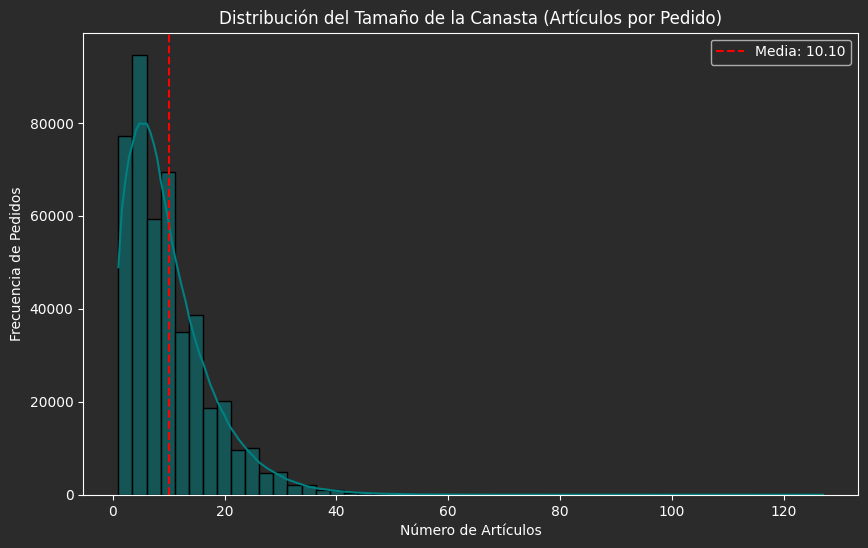

Media de artículos por orden: 10.10
Mediana de artículos por orden: 8.0
Curtosis de la distribución: 4.13


In [115]:
# El tamaño de la canasta comercial
articulos_por_orden = order_products.groupby('order_id')['product_id'].count()

plt.figure(figsize=(10, 6))
sns.histplot(articulos_por_orden, bins=50, kde=True, color='teal')
plt.title('Distribución del Tamaño de la Canasta (Artículos por Pedido)')
plt.xlabel('Número de Artículos')
plt.ylabel('Frecuencia de Pedidos')
plt.axvline(articulos_por_orden.mean(), color='red', linestyle='--', label=f'Media: {articulos_por_orden.mean():.2f}')
plt.legend()
plt.show()

print(f"Media de artículos por orden: {articulos_por_orden.mean():.2f}")
print(f"Mediana de artículos por orden: {articulos_por_orden.median()}")
print(f"Curtosis de la distribución: {articulos_por_orden.kurt():.2f}")


**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

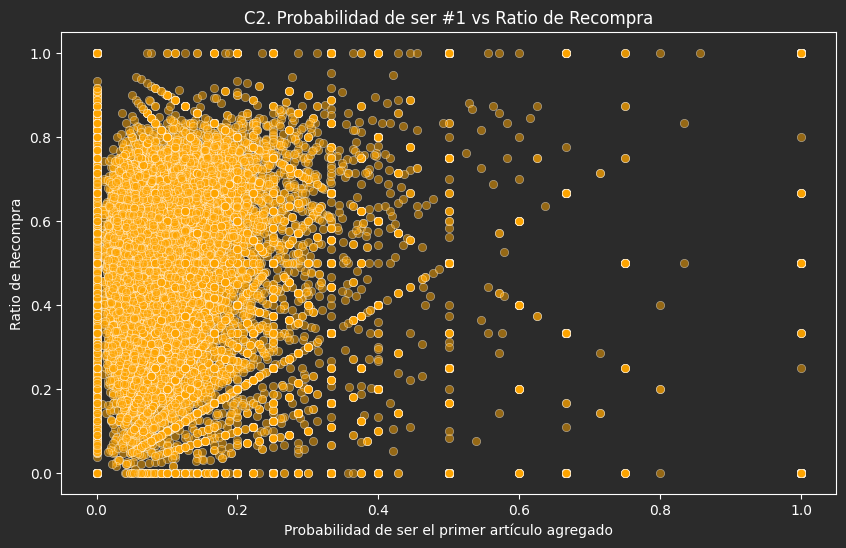

Correlación de Spearman (Fidelidad vs Posición #1): 0.2211


In [116]:
# Correlación ser #1 vs Ratio de Recompra
# Nota: add_to_cart_order == 1 excluye naturalmente los -1 imputados en 2.2
stats_prod = order_products.groupby('product_id').agg(
    total_pedidos=('order_id', 'count'),
    veces_primero=('add_to_cart_order', lambda x: (x == 1).sum()),
    ratio_recompra=('reordered', 'mean')
)
stats_prod['prob_primero'] = stats_prod['veces_primero'] / stats_prod['total_pedidos']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=stats_prod, x='prob_primero', y='ratio_recompra', alpha=0.5, color='orange')
plt.title('C2. Probabilidad de ser #1 vs Ratio de Recompra')
plt.xlabel('Probabilidad de ser el primer artículo agregado')
plt.ylabel('Ratio de Recompra')
plt.show()

# Coeficiente de correlación
corr_spearman = stats_prod['prob_primero'].corr(stats_prod['ratio_recompra'], method='spearman')
print(f"Correlación de Spearman (Fidelidad vs Posición #1): {corr_spearman:.4f}")


**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [117]:
# Proporción de re-compras por producto (Top 10)
recompra_por_producto = order_products.groupby('product_id')['reordered'].mean().sort_values(ascending=False)
recompra_por_producto_nombres = products.set_index('product_id')['product_name']

print("C3. Top 10 productos con mayor proporción de re-compra:")
top_recompra_prod = recompra_por_producto.head(10).to_frame()
top_recompra_prod['product_name'] = top_recompra_prod.index.map(recompra_por_producto_nombres)
top_recompra_prod['total_pedidos'] = top_recompra_prod.index.map(stats_prod['total_pedidos'])
display(top_recompra_prod[['product_name', 'reordered', 'total_pedidos']])

C3. Top 10 productos con mayor proporción de re-compra:


,product_name,reordered,total_pedidos
product_id,,,
30644,Organic French Roast,1.0,2
8054,Bissli Smokey Wheat Snacks,1.0,1
30650,Mushroom Lover's Veggie Burgers,1.0,2
44747,Frozen Organic Blackberries,1.0,1
44743,Real Zero Cola,1.0,2
35897,Ham Hock,1.0,1
35834,Bulgarian Organic Yogurt,1.0,2
2939,Cheddar Crunchin' Crackers,1.0,7
22209,Temples Earl Gray Strong Tea,1.0,2


**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

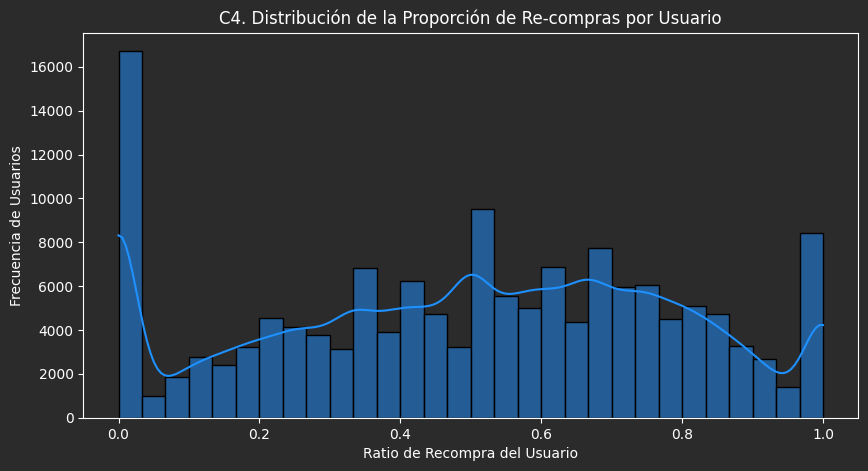

Promedio de recompra por usuario: 49.50%


In [118]:
# Proporción de re-compras por usuario (Distribución)
recompra_por_usuario = obt.groupby('user_id')['reordered'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(recompra_por_usuario, bins=30, kde=True, color='dodgerblue')
plt.title('C4. Distribución de la Proporción de Re-compras por Usuario')
plt.xlabel('Ratio de Recompra del Usuario')
plt.ylabel('Frecuencia de Usuarios')
plt.show()

print(f"Promedio de recompra por usuario: {recompra_por_usuario.mean():.2%}")

**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

In [119]:
# Identificar productos que más veces se ponen primero
# Nota: add_to_cart_order == 1 excluye naturalmente los -1 imputados en 2.2
top_20_primero_ids = order_products[order_products['add_to_cart_order'] == 1]['product_id'].value_counts().head(20)
top_20_primero_df = products[products['product_id'].isin(top_20_primero_ids.index)][['product_id', 'product_name']]
top_20_primero_df['conteo_primero'] = top_20_primero_df['product_id'].map(top_20_primero_ids)
top_20_primero_df = top_20_primero_df.sort_values(by='conteo_primero', ascending=False)

print("C5. Top 20 productos que los clientes ponen primero en sus carritos:")
display(top_20_primero_df[['product_name', 'conteo_primero']])

C5. Top 20 productos que los clientes ponen primero en sus carritos:


,product_name,conteo_primero
24209,Banana,15562
12831,Bag of Organic Bananas,11026
27119,Organic Whole Milk,4363
20592,Organic Strawberries,3946
45924,Organic Hass Avocado,3390
21337,Organic Baby Spinach,3336
46459,Organic Avocado,3044
19142,Spring Water,2336
16359,Strawberries,2308
27237,Organic Raspberries,2024


### Tus conclusiones avanzadas [Grupo C]:
1. **Dinámica del Carrito (C1):** El tamaño promedio de la canasta es de **10.10 artículos**, con una distribución que presenta una **curtosis de 4.13 (leptocúrtica)**. Esto indica que la mayoría de los pedidos se concentran fuertemente cerca de la media, pero existe una presencia significativa de pedidos de gran tamaño que extienden la distribución.
2. **Psicología de la Compra (C2/C5):** Existe una correlación positiva débil-moderada (Spearman **0.22**) entre ser el primer producto agregado al carrito y el ratio de recompra. Esto sugiere que, aunque ser posicionado primero es un indicador de fidelidad para ciertos productos ancla, no es una regla universal para todo el catálogo.
3. **Lealtad del Producto (C3):** Los productos con ratio 1.0 corresponden a artículos con muy baja frecuencia (1-2 pedidos), por lo que el ratio perfecto no es significativo estadísticamente. Para un análisis más robusto, el foco debería estar en productos con alto volumen Y alto ratio de recompra, como los identificados en B2.
4. **Perfil de Recompra del Usuario (C4):** El usuario promedio recompra aproximadamente el **49.49%** de los artículos de su carrito, lo que demuestra una alta dependencia del inventario histórico del cliente para las ventas recurrentes.

# Conclusión General Ejecutiva
Instacart presenta un ecosistema de datos robusto pero con desafíos técnicos heredados, como el truncamiento en 30 días y el desbordamiento en el orden del carrito (>64 artículos). La principal fortaleza del negocio reside en la **alta recurrencia semanal** y la lealtad hacia productos perecederos (frutas y vegetales), que actúan como "productos ancla" (frecuentemente posicionados #1). Se detectó una pérdida mínima de integridad referencial durante la construcción de la OBT (~0.25%), lo que valida la calidad de la gobernanza actual tras los procesos de limpieza. Como recomendación estratégica, la directiva debería incentivar la inclusión de productos de "impulso" una vez que el producto ancla ha sido añadido, aprovechando el disparador de compra identificado en el análisis de causalidad.